In [1]:
import h5py
import o2sclpy
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns

In [5]:
eos_params = ['a','alpha','param_S','param_L','exp1','trans1','exp2','trans2','exp3']
R_list = [f"R_{i}" for i in range(100)]

In [6]:
o2scl_settings=o2sclpy.lib_settings_class()
hf=o2sclpy.hdf_file()
print('PyModule : Reading test file: ')
hf.open('aff_inv/np_all2') # Required to be passed
tab=o2sclpy.table()
name=b''
o2sclpy.hdf_input_table(hf,tab,name)
hf.close()

PyModule : Reading test file: 


In [7]:
def read_tab(tab,list):
  X=[]
  for i in list:
    X.append(tab[i][0:tab.get_nlines()])
  X = np.asarray(X).transpose()
  return X

In [8]:
input = read_tab(tab,eos_params)
output = read_tab(tab,R_list)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(input, output, test_size=0.2, random_state=42)

In [10]:
emu_dtr=o2sclpy.interpm_sklearn_dtr()
emu_dtr.set_data(X_train,y_train)

In [11]:
y_pred=emu_dtr.eval(X_test[0])
print(y_pred,y_test[0])

[[17.63767005 16.19676667 15.28586903 14.66720925 14.21331174 13.88586499
  13.63311611 13.43670927 13.2828902  13.16148555 13.06482307 12.98718542
  12.92433143 12.87307329 12.83103419 12.79885503 12.77306755 12.75173905
  12.73544711 12.72357288 12.71382121 12.70770456 12.70346064 12.70086407
  12.7004223  12.70052409 12.7025821  12.70482179 12.70828793 12.71192232
  12.71630679 12.72075383 12.72547944 12.73009223 12.73403039 12.7378016
  12.74024509 12.74250934 12.74303599 12.74335957 12.74167252 12.73971917
  12.7356045  12.73109444 12.72436136 12.71701901 12.70750679 12.69706404
  12.68462734 12.67080112 12.65528928 12.63774565 12.6189795  12.59735386
  12.5748141  12.54903535 12.52166512 12.49205602 12.45924461 12.42462634
  12.38655127 12.34516695 12.30105894 12.25312924 12.19919797 12.1261226
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.   

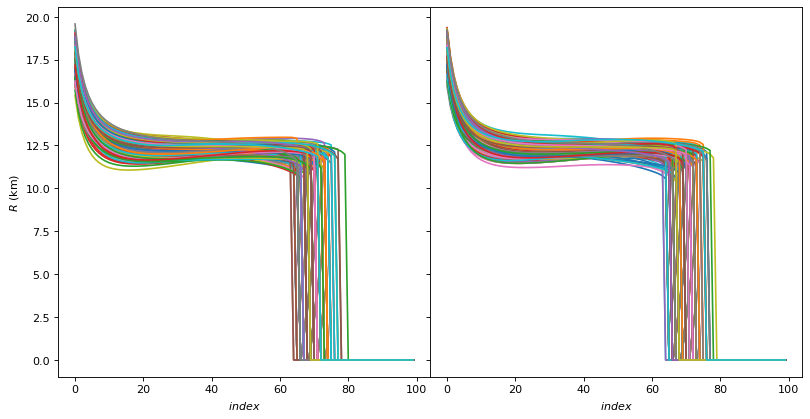

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, sharex=True,figsize=(12, 6),dpi=80,gridspec_kw={'hspace': 0, 'wspace': 0})
axes.flatten()
axes[0].set_ylabel(r"$R~(\mathrm{km})$")
axes[0].set_xlabel(r"$index$")
axes[1].set_xlabel(r"$index$")
for i in range(0,len(y_test)):
  axes[0].plot(y_test[i])
  axes[1].plot(emu_dtr.eval(X_test[i])[0])

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

model=DecisionTreeRegressor()

param_grid = {
    #'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10, 12, 14, 15],
    'max_features': [None],
    'criterion': ['absolute_error']
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1,verbose = 2,return_train_score=True)
# Fit the model
grid_search.fit(X_train, y_train)
# Get best regressor
best_regressor = grid_search.best_estimator_


Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END criterion=absolute_error, max_features=None, min_samples_leaf=5, min_samples_split=2; total time=  13.4s
[CV] END criterion=absolute_error, max_features=None, min_samples_leaf=5, min_samples_split=10; total time=  13.6s
[CV] END criterion=absolute_error, max_features=None, min_samples_leaf=1, min_samples_split=5; total time=  13.8s
[CV] END criterion=absolute_error, max_features=None, min_samples_leaf=5, min_samples_split=10; total time=  13.8s
[CV] END criterion=absolute_error, max_features=None, min_samples_leaf=5, min_samples_split=10; total time=  13.8s
[CV] END criterion=absolute_error, max_features=None, min_samples_leaf=5, min_samples_split=2; total time=  13.9s
[CV] END criterion=absolute_error, max_features=None, min_samples_leaf=5, min_samples_split=5; total time=  13.9s
[CV] END criterion=absolute_error, max_features=None, min_samples_leaf=1, min_samples_split=2; total time=  14.0s
[CV] END criterion=absol

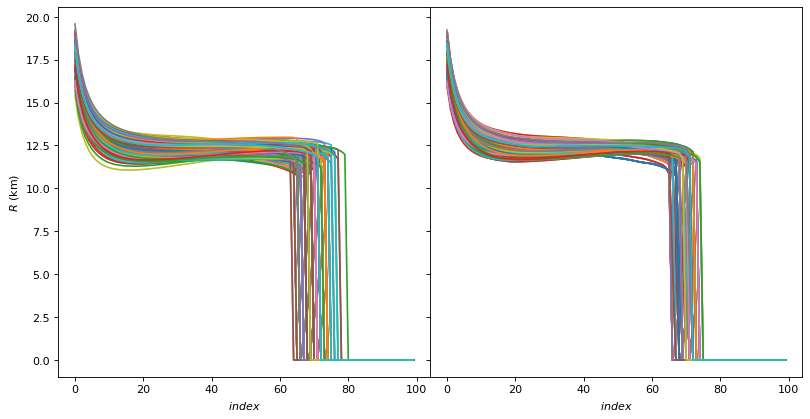

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, sharex=True,figsize=(12, 6),dpi=80,gridspec_kw={'hspace': 0, 'wspace': 0})
axes.flatten()
axes[0].set_ylabel(r"$R~(\mathrm{km})$")
axes[0].set_xlabel(r"$index$")
axes[1].set_xlabel(r"$index$")
for i in range(0,len(y_test)):
  axes[0].plot(y_test[i])
  axes[1].plot(best_regressor.predict([X_test[i]])[0])

In [15]:
best_regressor.predict([X_test[i]])[0]

array([18.35488909, 16.77492562, 15.75738637, 15.05276242, 14.54309892,
       14.1568222 , 13.86031484, 13.62283184, 13.43281635, 13.27821826,
       13.14993159, 13.04249532, 12.95167021, 12.87415865, 12.80739384,
       12.74986412, 12.70068781, 12.65750346, 12.61992015, 12.58768303,
       12.56206952, 12.54031235, 12.52186601, 12.50806683, 12.49577037,
       12.48691555, 12.4791518 , 12.4730173 , 12.46758744, 12.46270493,
       12.45807895, 12.45351086, 12.44888961, 12.44401007, 12.43880077,
       12.43317365, 12.42697143, 12.42025313, 12.41271041, 12.40464264,
       12.39547128, 12.38576358, 12.37479484, 12.3631897 , 12.35025856,
       12.33654764, 12.32144598, 12.30541676, 12.28782057, 12.26923121,
       12.24889159, 12.22760799, 12.20426636, 12.17974753, 12.15336721,
       12.12497419, 12.09513351, 12.06272957, 12.02832867, 11.99156137,
       11.95211482, 11.90990917, 11.86438374, 11.81527731, 11.76224847,
       11.70458274, 11.63894067,  8.65124821,  2.89492241,  0.  

In [26]:
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

Best parameters: {'criterion': 'absolute_error', 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [ ]:
bes